In [1]:
!pip install pandas
!pip install scanpy
!pip install matplotlib
!pip install numpy
!pip install scikit-learn
!pip install seaborn
!pip install requests
!pip install tempfile


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement tempfile (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tempfile


In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as ppyplot
import numpy as np
import requests
import tempfile

In [3]:
def load_from_url(url):
    response = requests.get(url)
    with tempfile.NamedTemporaryFile(suffix=".h5ad", delete=False) as tmp_file:
        tmp_file.write(response.content)
        tmp_file.flush()
        tmp_path = tmp_file.name
    return sc.read_h5ad(tmp_path)




ad_url = "https://datasets.cellxgene.cziscience.com/42f1ec32-aaa2-4f08-8f78-a34f9b993ea8.h5ad"
adata = load_from_url(ad_url)


In [4]:
adata.obs
adata.obs["disease"]

6-MTL_WM             leukoencephalopathy, diffuse hereditary, with ...
44-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
77-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
106-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
126-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
                                           ...                        
144337-Sample_140                                    Alzheimer disease
144345-Sample_140                                    Alzheimer disease
144401-Sample_140                                    Alzheimer disease
144468-Sample_140                                    Alzheimer disease
144511-Sample_140                                    Alzheimer disease
Name: disease, Length: 24342, dtype: category
Categories (3, object): ['Alzheimer disease', 'leukoencephalopathy, diffuse hereditary, with..., 'normal']

In [5]:

adata.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,feature_name,feature_reference,feature_biotype,feature_length,feature_type
new_index,,,,,,,,,,,,,,,
ENSG00000186827,False,False,False,False,4.171703e-04,0.951378,-0.990631,TNFRSF4,False,ENSG00000186827.11,TNFRSF4,NCBITaxon:9606,gene,1039,protein_coding
ENSG00000186891,False,False,False,False,4.951178e-03,2.227100,1.150319,TNFRSF18,False,ENSG00000186891.14,TNFRSF18,NCBITaxon:9606,gene,789,protein_coding
ENSG00000160072,False,False,False,False,1.745004e-01,1.814032,0.457097,ATAD3B,False,ENSG00000160072.20,ATAD3B,NCBITaxon:9606,gene,3300,protein_coding
ENSG00000260179,False,False,False,False,1.754614e-03,1.259363,-0.473763,ENSG00000260179.1,False,ENSG00000260179.1,ENSG00000260179,NCBITaxon:9606,gene,1558,lncRNA
ENSG00000234396,False,False,False,False,3.883246e-03,1.997757,0.765430,ENSG00000234396.3,False,ENSG00000234396.3,ENSG00000234396,NCBITaxon:9606,gene,326,lncRNA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,False,False,False,False,1.250553e-01,1.761595,0.369096,ENSG00000271254.7,False,ENSG00000271254.7,ENSG00000271254,NCBITaxon:9606,gene,2922,protein_coding
ENSG00000275987,False,False,False,False,5.155446e-04,0.486031,-1.771590,U1-4,False,ENSG00000275987.1,U1,NCBITaxon:9606,gene,144,snRNA
ENSG00000268674,False,False,False,False,6.859217e-05,0.512661,-1.726899,ENSG00000268674.2,False,ENSG00000268674.2,ENSG00000268674,NCBITaxon:9606,gene,510,protein_coding


In [6]:
adata.var["Mito"] = adata.var_names.str.startswith("MT")
sc.pp.calculate_qc_metrics(adata, qc_vars=["Mito"], inplace=True, percent_top=[50])

In [7]:
adata.obs.columns

Index(['APOE', 'Brain.Region', 'SORT', 'Braak.stage', 'Amyloid',
       'Brain.weight', 'PMI.hr.', 'RIN', 'Gray.vs.White', 'n_genes_by_counts',
       'total_counts', 'pct_counts_ribo', 'pct_counts_hb', 'pct_counts_mt',
       'n_counts', 'n_genes', '20_leiden_1.0', 'Sample', '8_PCs_Leiden_0.3',
       'log_n_counts', 'Molecule', 'single_or_paired_end', 'Instrument',
       'donor_id', 'development_stage_ontology_term_id',
       'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id',
       'cell_type_ontology_term_id', 'assay_ontology_term_id',
       'suspension_type', 'Oligodendrocyte_Clusters', 'is_primary_data',
       'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'development_stage', 'observation_joinid',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'total_counts_Mito',
       'log1p_total_counts_Mito', 'pc

In [8]:
adata.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,...,feature_biotype,feature_length,feature_type,Mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
new_index,,,,,,,,,,,,,,,,,,,,,
ENSG00000186827,False,False,False,False,4.171703e-04,0.951378,-0.990631,TNFRSF4,False,ENSG00000186827.11,...,gene,1039,protein_coding,False,5,0.000214,0.000214,99.979459,5.213580,1.826737
ENSG00000186891,False,False,False,False,4.951178e-03,2.227100,1.150319,TNFRSF18,False,ENSG00000186891.14,...,gene,789,protein_coding,False,32,0.001781,0.001779,99.868540,43.352261,3.792164
ENSG00000160072,False,False,False,False,1.745004e-01,1.814032,0.457097,ATAD3B,False,ENSG00000160072.20,...,gene,3300,protein_coding,False,1453,0.074961,0.072285,94.030893,1824.708862,7.509724
ENSG00000260179,False,False,False,False,1.754614e-03,1.259363,-0.473763,ENSG00000260179.1,False,ENSG00000260179.1,...,gene,1558,lncRNA,False,18,0.000818,0.000818,99.926054,19.909603,3.040209
ENSG00000234396,False,False,False,False,3.883246e-03,1.997757,0.765430,ENSG00000234396.3,False,ENSG00000234396.3,...,gene,326,lncRNA,False,21,0.001315,0.001314,99.913729,31.998207,3.496453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,False,False,False,False,1.250553e-01,1.761595,0.369096,ENSG00000271254.7,False,ENSG00000271254.7,...,gene,2922,protein_coding,False,1287,0.057258,0.055679,94.712842,1393.786011,7.240496
ENSG00000275987,False,False,False,False,5.155446e-04,0.486031,-1.771590,U1-4,False,ENSG00000275987.1,...,gene,144,snRNA,False,10,0.000317,0.000317,99.958919,7.712062,2.164709
ENSG00000268674,False,False,False,False,6.859217e-05,0.512661,-1.726899,ENSG00000268674.2,False,ENSG00000268674.2,...,gene,510,protein_coding,False,1,0.000040,0.000040,99.995892,0.981977,0.684095


In [9]:
adata.var["Mito"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, percent_top=[50], qc_vars=["Mito"], inplace=True)

In [10]:
sc.pp.filter_genes(adata, min_cells=200)

In [11]:
sc.pp.filter_cells(adata, min_genes=100)

In [12]:
adata.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,...,feature_length,feature_type,Mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
new_index,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,False,False,False,False,0.174500,1.814032,0.457097,ATAD3B,False,ENSG00000160072.20,...,3300,protein_coding,False,1453,0.074961,0.072285,94.030893,1824.708862,7.509724,1453
ENSG00000142611,False,False,False,False,0.065214,1.937938,0.665040,PRDM16,False,ENSG00000142611.17,...,3730,protein_coding,False,566,0.026447,0.026104,97.674801,643.783508,6.468915,566
ENSG00000131584,False,False,False,False,0.549589,1.961516,0.762521,ACAP3,False,ENSG00000131584.19,...,819,protein_coding,False,4547,0.260317,0.231364,81.320352,6336.640625,8.754262,4547
ENSG00000157911,False,False,False,False,0.033176,1.550995,0.015661,PEX10,False,ENSG00000157911.11,...,907,protein_coding,False,301,0.014544,0.014439,98.763454,354.033661,5.872212,301
ENSG00000224051,False,False,False,False,0.041789,1.653626,0.187900,CPTP,False,ENSG00000224051.7,...,1101,protein_coding,False,425,0.019124,0.018943,98.254047,465.506561,6.145272,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000276256,False,False,False,False,0.054307,1.518059,-0.039612,ENSG00000276256.1,False,ENSG00000276256.1,...,2195,protein_coding,False,570,0.025356,0.025040,97.658368,617.226868,6.426856,570
ENSG00000273748,False,False,False,False,0.571783,1.796372,-0.031962,ENSG00000273748.1,False,ENSG00000273748.1,...,372,protein_coding,False,5268,0.291468,0.255780,78.358393,7094.916992,8.867275,5268
ENSG00000278817,False,False,False,False,0.024637,1.777714,0.396149,ENSG00000278817.1,False,ENSG00000278817.1,...,1213,protein_coding,False,213,0.010355,0.010302,99.124969,252.070557,5.533669,213


In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [14]:
sc.pp.highly_variable_genes(adata, flavor='seurat', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable']]


c:\Users\14432\AppData\Local\Programs\Python\Python312\Lib\site-packages\scanpy\preprocessing\_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


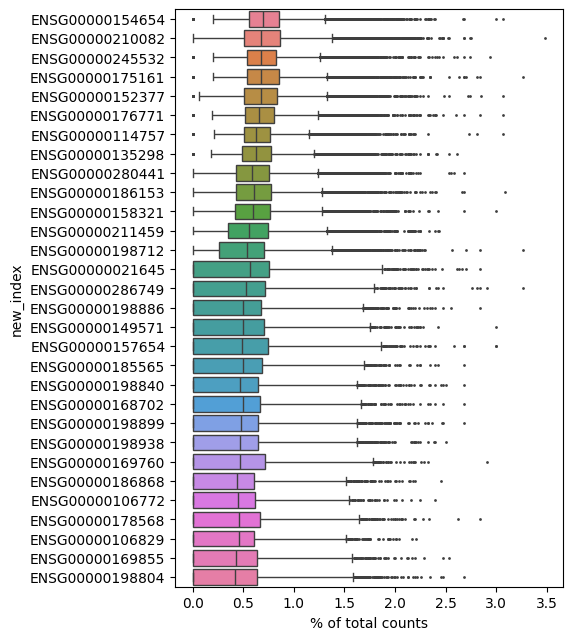

In [15]:
sc.pl.highest_expr_genes(adata)

In [16]:
sc.pp.scale(adata)

c:\Users\14432\AppData\Local\Programs\Python\Python312\Lib\functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:
sc.pp.pca(adata)
sc.pp.normalize_total(adata, exclude_highly_expressed = True, inplace=True, target_sum = 1e4)

c:\Users\14432\AppData\Local\Programs\Python\Python312\Lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [18]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)

c:\Users\14432\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


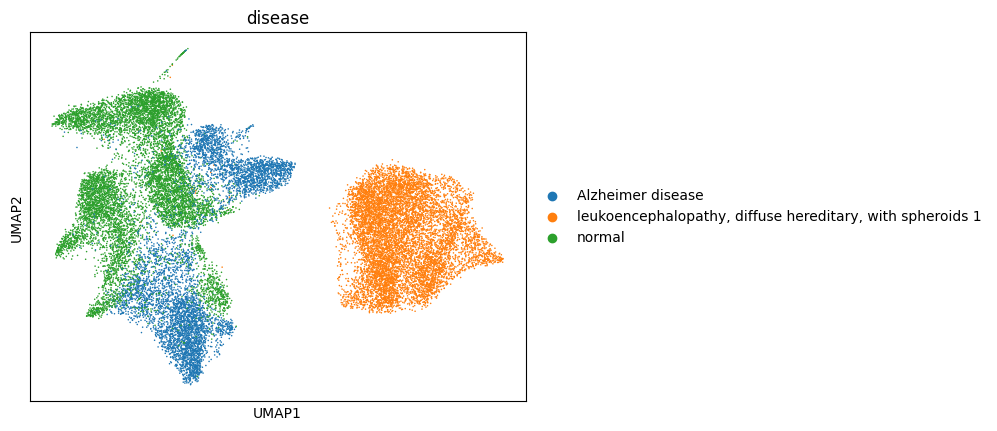

In [19]:
sc.pl.umap(adata, color="disease")

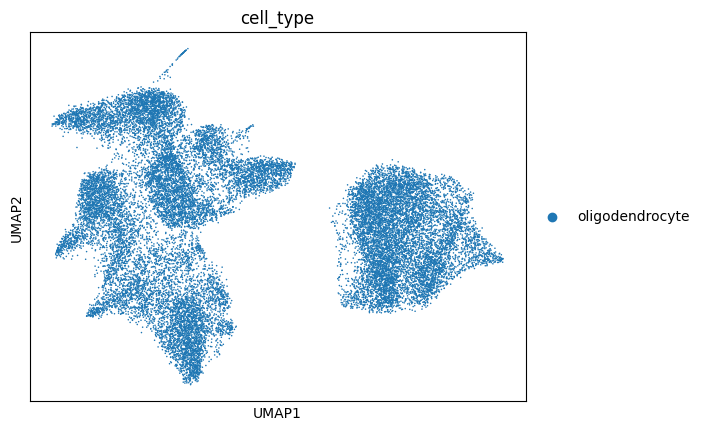

In [20]:
sc.pl.umap(adata, color="cell_type")

In [21]:
nan_values = adata.obs.isnull().any(axis=1).copy()

In [22]:
nan_values.count

<bound method Series.count of 6-MTL_WM             False
44-MTL_WM            False
77-MTL_WM            False
106-MTL_WM           False
126-MTL_WM           False
                     ...  
144337-Sample_140     True
144345-Sample_140     True
144401-Sample_140     True
144468-Sample_140     True
144511-Sample_140     True
Length: 24342, dtype: bool>

In [23]:
new_adata = adata[~nan_values].copy()

In [24]:
new_adata.obs

,APOE,Brain.Region,SORT,Braak.stage,Amyloid,Brain.weight,PMI.hr.,RIN,Gray.vs.White,n_genes_by_counts,...,tissue,self_reported_ethnicity,development_stage,observation_joinid,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_50_genes,total_counts_Mito,log1p_total_counts_Mito,pct_counts_Mito
6-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,991,...,white matter of temporal lobe,European,72-year-old stage,0b*^?3z<35,6.899723,7.689979,8.691307,0.0,0.0,0.0
44-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,760,...,white matter of temporal lobe,European,72-year-old stage,rRUZAD#H$=,6.634633,7.534247,10.473275,0.0,0.0,0.0
77-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,580,...,white matter of temporal lobe,European,72-year-old stage,;E{vC#|}Wl,6.364751,7.378717,12.168860,0.0,0.0,0.0
106-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,779,...,white matter of temporal lobe,European,72-year-old stage,r<T9CWQrcN,6.659294,7.552385,10.081000,0.0,0.0,0.0
126-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,2386,...,white matter of temporal lobe,European,72-year-old stage,xt{eA>*-n_,7.777793,8.096650,5.544508,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148475-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,3215,...,prefrontal cortex,unknown,83-year-old stage,toCS)s7VV6,8.075894,8.246785,4.531563,0.0,0.0,0.0
148498-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,4080,...,prefrontal cortex,unknown,83-year-old stage,p%<o_lw`x-,8.314097,8.294127,4.323674,0.0,0.0,0.0
148736-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,2317,...,prefrontal cortex,unknown,83-year-old stage,n&lNii}m8c,7.748460,8.120696,5.205448,0.0,0.0,0.0
148783-Sample_46,E3/E3,Frontal,Pax6/NeuNneg,IV,C1,1375.0,19.5,5.2,gray/wm,2422,...,prefrontal cortex,unknown,83-year-old stage,MaujRC@Ki6,7.792762,8.132295,5.066612,0.0,0.0,0.0


In [25]:
print(new_adata.obs["disease"].value_counts())

disease
leukoencephalopathy, diffuse hereditary, with spheroids 1    8939
Alzheimer disease                                            3635
normal                                                       3233
Name: count, dtype: int64


In [26]:
oligos_subset = adata[adata.obs["cell_type"]=="oligodendrocyte"]

In [27]:
oligos_subset.obs

,APOE,Brain.Region,SORT,Braak.stage,Amyloid,Brain.weight,PMI.hr.,RIN,Gray.vs.White,n_genes_by_counts,...,tissue,self_reported_ethnicity,development_stage,observation_joinid,log1p_n_genes_by_counts,log1p_total_counts,pct_counts_in_top_50_genes,total_counts_Mito,log1p_total_counts_Mito,pct_counts_Mito
6-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,991,...,white matter of temporal lobe,European,72-year-old stage,0b*^?3z<35,6.899723,7.689979,8.691307,0.0,0.0,0.0
44-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,760,...,white matter of temporal lobe,European,72-year-old stage,rRUZAD#H$=,6.634633,7.534247,10.473275,0.0,0.0,0.0
77-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,580,...,white matter of temporal lobe,European,72-year-old stage,;E{vC#|}Wl,6.364751,7.378717,12.168860,0.0,0.0,0.0
106-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,779,...,white matter of temporal lobe,European,72-year-old stage,r<T9CWQrcN,6.659294,7.552385,10.081000,0.0,0.0,0.0
126-MTL_WM,E3/E4,Medial temporal,DAPI,IV,C1,1355.0,24.0,4.3,wm,2386,...,white matter of temporal lobe,European,72-year-old stage,xt{eA>*-n_,7.777793,8.096650,5.544508,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144337-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,3553,...,prefrontal cortex,unknown,81-year-old stage,3Z<xyGh{N!,8.175829,8.261338,4.504398,0.0,0.0,0.0
144345-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,2167,...,prefrontal cortex,unknown,81-year-old stage,c0+G|(adYP,7.681560,8.084967,5.490188,0.0,0.0,0.0
144401-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,2725,...,prefrontal cortex,unknown,81-year-old stage,wziL<se?K!,7.910591,8.160071,5.040737,0.0,0.0,0.0
144468-Sample_140,E3/E4,Frontal,Pax6/NeuNneg,III,Diffuse plaques,NaN,10.0,6.1,gray/wm,1282,...,prefrontal cortex,unknown,81-year-old stage,B}fZT(i#NE,7.156956,7.867307,6.635993,0.0,0.0,0.0


In [28]:
oligos_subset.obs["cell_type"]

6-MTL_WM             oligodendrocyte
44-MTL_WM            oligodendrocyte
77-MTL_WM            oligodendrocyte
106-MTL_WM           oligodendrocyte
126-MTL_WM           oligodendrocyte
                          ...       
144337-Sample_140    oligodendrocyte
144345-Sample_140    oligodendrocyte
144401-Sample_140    oligodendrocyte
144468-Sample_140    oligodendrocyte
144511-Sample_140    oligodendrocyte
Name: cell_type, Length: 24342, dtype: category
Categories (1, object): ['oligodendrocyte']

In [29]:
print(oligos_subset.X)

[[-0.14354296 -0.4528689  -0.47211212 ... -0.09744048 -0.53909932
  -0.11826215]
 [-0.14354296 -0.4528689  -0.47211212 ... -0.09744048 -0.53909932
  -0.11826215]
 [-0.14354296 -0.4528689  -0.47211212 ... -0.09744048 -0.53909932
  -0.11826215]
 ...
 [-0.14354296 -0.4528689  -0.47211212 ... -0.09744048 -0.53909932
  -0.11826215]
 [-0.14354296 -0.4528689  -0.47211212 ... -0.09744048 -0.53909932
  -0.11826215]
 [-0.14354296 -0.4528689   1.03379212 ... -0.09744048 -0.53909932
  -0.11826215]]


In [30]:
new_adata.obs["disease"]

6-MTL_WM            leukoencephalopathy, diffuse hereditary, with ...
44-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
77-MTL_WM           leukoencephalopathy, diffuse hereditary, with ...
106-MTL_WM          leukoencephalopathy, diffuse hereditary, with ...
126-MTL_WM          leukoencephalopathy, diffuse hereditary, with ...
                                          ...                        
148475-Sample_46                                    Alzheimer disease
148498-Sample_46                                    Alzheimer disease
148736-Sample_46                                    Alzheimer disease
148783-Sample_46                                    Alzheimer disease
148846-Sample_46                                    Alzheimer disease
Name: disease, Length: 15807, dtype: category
Categories (3, object): ['Alzheimer disease', 'leukoencephalopathy, diffuse hereditary, with..., 'normal']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance



In [32]:
X_data = new_adata.X
y_label = new_adata.obs["disease"]
X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.33, stratify=y_label)
model = LogisticRegression(solver='lbfgs', C=0.1, class_weight="balanced", max_iter=1000)
model.fit(X_train, y_train)
class_label_predictions = model.predict_proba(X_test)
pred = model.predict(X_test)
acc_score = accuracy_score(y_test, pred)

print(acc_score)


0.9986582327007859


In [33]:
conf_matrix = confusion_matrix(y_test, pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[1196    0    4]
 [   1 2948    1]
 [   1    0 1066]]


In [34]:
class_report = classification_report(y_test, pred)
print("Classification Report:")
print(class_report)

Classification Report:
                                                           precision    recall  f1-score   support

                                        Alzheimer disease       1.00      1.00      1.00      1200
leukoencephalopathy, diffuse hereditary, with spheroids 1       1.00      1.00      1.00      2950
                                                   normal       1.00      1.00      1.00      1067

                                                 accuracy                           1.00      5217
                                                macro avg       1.00      1.00      1.00      5217
                                             weighted avg       1.00      1.00      1.00      5217




[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


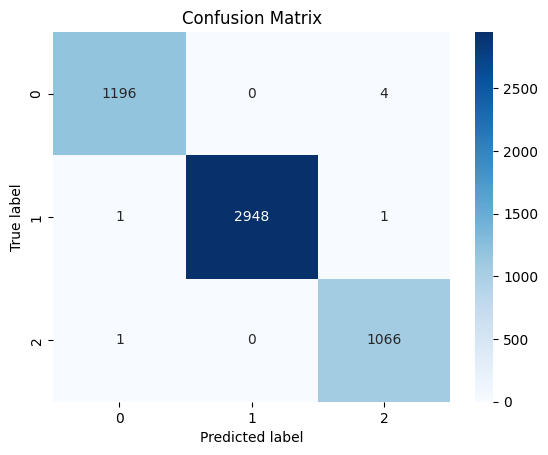

In [35]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [36]:
sfm = SelectFromModel(model, prefit=True, threshold="mean")  
X_train_selected = sfm.transform(X_train)
X_test_selected = sfm.transform(X_test)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train.shape[1]}")

Selected 672 features out of 2000


In [37]:
selected_mask = sfm.get_support()  
selected_genes = new_adata.var_names[selected_mask]  
print(selected_genes)
print(type(selected_genes))

Index(['ENSG00000131584', 'ENSG00000230021', 'ENSG00000232423',
       'ENSG00000055070', 'ENSG00000084628', 'ENSG00000189337',
       'ENSG00000237480', 'ENSG00000117525', 'ENSG00000143156',
       'ENSG00000047410',
       ...
       'ENSG00000234129', 'ENSG00000289591', 'ENSG00000203930',
       'ENSG00000286217', 'ENSG00000176728', 'ENSG00000067646',
       'ENSG00000067048', 'ENSG00000183878', 'ENSG00000241859',
       'ENSG00000165246'],
      dtype='object', name='new_index', length=672)
<class 'pandas.core.indexes.base.Index'>


In [38]:
selected = list(selected_genes)

# Extract gene names
selected_gene_symbols = new_adata.var.loc[selected_genes, "gene_name"]

print(selected_gene_symbols)


new_index
ENSG00000131584                 ACAP3
ENSG00000230021    ENSG00000230021.10
ENSG00000232423               PRAMEF6
ENSG00000055070                 SZRD1
ENSG00000084628                NKAIN1
                          ...        
ENSG00000067646                   ZFY
ENSG00000067048                 DDX3Y
ENSG00000183878                   UTY
ENSG00000241859                ANOS2P
ENSG00000165246                NLGN4Y
Name: gene_name, Length: 672, dtype: object


In [39]:
#Talk to Majoie abt accuracy 
      #Overfit --> maybe not removing the NAN values, 
      #Reading papers on a similar papers -->

#Create a new dataset with these filtered genes
selected_genes = list(set(selected_genes).intersection(set(adata.var_names)))
selected_genes



#Combine this dataset with the cereb data 

#Find genes if they correlate with cereb data

#Train maybe a neural net for this? or do feature importance with SHAP?

['ENSG00000148219',
 'ENSG00000151693',
 'ENSG00000137251',
 'ENSG00000110958',
 'ENSG00000187135',
 'ENSG00000173077',
 'ENSG00000215067',
 'ENSG00000143156',
 'ENSG00000162614',
 'ENSG00000141314',
 'ENSG00000177469',
 'ENSG00000145147',
 'ENSG00000168246',
 'ENSG00000150656',
 'ENSG00000258891',
 'ENSG00000198728',
 'ENSG00000171843',
 'ENSG00000185737',
 'ENSG00000198707',
 'ENSG00000099875',
 'ENSG00000125462',
 'ENSG00000152578',
 'ENSG00000113578',
 'ENSG00000008513',
 'ENSG00000115484',
 'ENSG00000154645',
 'ENSG00000080224',
 'ENSG00000137270',
 'ENSG00000258312',
 'ENSG00000115239',
 'ENSG00000147202',
 'ENSG00000259462',
 'ENSG00000264808',
 'ENSG00000287635',
 'ENSG00000106278',
 'ENSG00000180071',
 'ENSG00000232451',
 'ENSG00000173230',
 'ENSG00000004846',
 'ENSG00000139971',
 'ENSG00000172318',
 'ENSG00000135636',
 'ENSG00000286293',
 'ENSG00000228793',
 'ENSG00000173482',
 'ENSG00000203805',
 'ENSG00000147862',
 'ENSG00000179869',
 'ENSG00000164292',
 'ENSG00000147316',


In [40]:
adata_combined = new_adata[:, selected_genes].copy()

In [41]:
adata_combined

AnnData object with n_obs × n_vars = 15807 × 672
    obs: 'APOE', 'Brain.Region', 'SORT', 'Braak.stage', 'Amyloid', 'Brain.weight', 'PMI.hr.', 'RIN', 'Gray.vs.White', 'n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_hb', 'pct_counts_mt', 'n_counts', 'n_genes', '20_leiden_1.0', 'Sample', '8_PCs_Leiden_0.3', 'log_n_counts', 'Molecule', 'single_or_paired_end', 'Instrument', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_type', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'Oligodendrocyte_Clusters', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'total_counts_Mito', 'log1p_total_counts_Mito', 'pct_counts_Mito'
    var: 'mt', 'ribo', 'hb', 'hi

In [42]:
adata_combined.var

,mt,ribo,hb,highly_variable,means,dispersions,dispersions_norm,gene_name,feature_is_filtered,gene_version,...,Mito,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,mean,std
new_index,,,,,,,,,,,,,,,,,,,,,
ENSG00000148219,False,False,False,True,1.523205,1.827747,1.098838,ASTN2,False,ENSG00000148219.18,...,False,12144,0.931964,0.658537,50.110919,22685.898438,10.029543,12144,0.988234,1.049071
ENSG00000151693,False,False,False,True,0.908439,1.953778,1.060110,ASAP2,False,ENSG00000151693.11,...,False,6400,0.393369,0.331725,73.707994,9575.381836,9.167055,6400,0.460504,0.813559
ENSG00000137251,False,False,False,True,0.150060,2.436889,2.574622,TINAG,False,ENSG00000137251.16,...,False,637,0.036872,0.036208,97.383124,897.535461,6.800766,637,0.044941,0.295426
ENSG00000110958,False,False,False,True,1.497812,1.924313,1.830036,PTGES3,False,ENSG00000110958.16,...,False,11594,0.878755,0.630610,52.370389,21390.646484,9.970756,11594,0.938063,1.051285
ENSG00000187135,False,False,False,True,0.797109,1.979660,1.081764,VSTM2B,False,ENSG00000187135.8,...,False,5514,0.331148,0.286042,77.347794,8060.801270,8.994892,5514,0.387344,0.754922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000013588,False,False,False,True,0.083828,2.409633,2.435876,GPRC5A,False,ENSG00000013588.9,...,False,281,0.019877,0.019682,98.845617,483.846191,6.183832,281,0.022849,0.220431
ENSG00000289591,False,False,False,True,1.348646,1.917101,1.429948,ENSG00000289591.1,False,ENSG00000289591.1,...,False,9728,0.771138,0.571622,60.036152,18771.064453,9.840125,9728,0.793290,1.015280
ENSG00000021645,False,False,False,True,2.109827,1.761032,1.558379,NRXN3,False,ENSG00000021645.20,...,False,16311,1.948791,1.081395,32.992359,47437.464844,10.767189,16311,1.597666,1.172687
